# MINI PROJECT 
## **Global Superstore Sales Analytics & Business Intelligence**

--------------------------------------------------------------------------------

**Global Superstore Sales Analytics**

Author : Athul C Ravindran

Project Type:
End-to-End Data Science Project

Dataset:
Global Superstore


Project Work Flow As planned;

1. Business Understanding
        
2. Data Collection
        
3. Data Understanding
        
4. Data Cleaning
        
5. Exploratory Data Analysis
        
6. Feature Engineering
        
7. Statistical Analysis
        
8. Machine Learning
        
9. Model Evaluation
        
10. Business Insights
        
11. Recommendations
        
12. Dashboard



Sales;
Which countries generate the highest revenue?
Which cities are losing money?
Which customer segments are most profitable?

Products;
Which products should be discontinued?
Which products are most profitable?
Which categories generate losses?

Customers;
Top customers
Repeat customers
Customer lifetime value
High-risk customers

Shipping;
Does faster shipping increase profit?
Which shipping mode costs the company more?

Geography;
Sales by Country
Sales by Region
Sales by State
Profit heatmaps

Time Series;
Monthly Sales Trend
Yearly Growth
Quarterly Revenue
Seasonal Analysis

Can be analysed!
Leading With Problems and Aim to resoolve it! that is the perspective taken here!
(*Random questions generated with the help of ChatGPT - finded out by using best logical solutions)

**Values are measured in Dollars**

Aim to present in the Industry standard.

**Business Problem**

Imagine you're hired as a Data Scientist by a multinational retail company.

The CEO asks:

"Our sales are increasing, but profits are not. Find out why, identify the major business problems, and help us improve profitability."

This becomes our business objective.


## Business Objectives

- Analyze overall sales performance.
- Identify profitable and loss-making products.
- Evaluate customer purchasing behavior.
- Analyze regional and segment-wise performance.
- Study the impact of discounts on profitability.
- Develop machine learning models to predict profit.
- Provide strategic business recommendations.



**Tools Used**

Python

Pandas

NumPy

Matplotlib

Seaborn

Plotly

Scikit-learn

Jupyter Notebook


In [1]:
#importing libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
#another recent discovered library
import plotly.express as px

#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

#slight tweaking for the visualisation
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("superstore.csv")

In [3]:
data = df.copy()

In [4]:
data.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [5]:
data.shape

(51290, 27)

## **Data Cleaning & Preprocessing**

In [6]:
missing = data.isnull().sum().sort_values(ascending=False)

missing

Category          0
Quantity          0
Market2           0
Year              0
Sub.Category      0
State             0
Shipping.Cost     0
Ship.Mode         0
Ship.Date         0
Segment           0
Sales             0
Row.ID            0
Region            0
Profit            0
City              0
Product.Name      0
Product.ID        0
Order.Priority    0
Order.ID          0
Order.Date        0
记录数               0
Market            0
Discount          0
Customer.Name     0
Customer.ID       0
Country           0
weeknum           0
dtype: int64

In [7]:
data.duplicated().sum()


np.int64(0)

In [8]:
data.nunique().sort_values()

记录数                   1
Category              3
Segment               3
Year                  4
Ship.Mode             4
Order.Priority        4
Market2               6
Market                7
Region               13
Quantity             14
Sub.Category         17
Discount             27
weeknum              53
Country             147
Customer.Name       795
State              1094
Order.Date         1430
Ship.Date          1464
Sales              2246
City               3636
Product.Name       3788
Customer.ID        4873
Product.ID        10292
Shipping.Cost     16877
Profit            24575
Order.ID          25035
Row.ID            51290
dtype: int64

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [10]:
#view datatypes
data.dtypes

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
记录数                 int64
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [11]:
#To Print numerical columns
num_cols = data.select_dtypes(include=np.number).columns

num_cols

Index(['Discount', '记录数', 'Profit', 'Quantity', 'Row.ID', 'Sales',
       'Shipping.Cost', 'Year', 'weeknum'],
      dtype='object')

In [12]:
data = data.drop(columns=['记录数'])   

In [13]:
num_cols = data.select_dtypes(include=np.number).columns

num_cols

Index(['Discount', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost',
       'Year', 'weeknum'],
      dtype='object')

In [14]:
#To print Categorical columns
cat_cols = data.select_dtypes(include="object").columns

cat_cols

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Market',
       'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID',
       'Product.Name', 'Region', 'Segment', 'Ship.Date', 'Ship.Mode', 'State',
       'Sub.Category', 'Market2'],
      dtype='object')

In [15]:
data.tail()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,2014-12-03 00:00:00.000,CA-2014-109701,High,...,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,2014-12-03 00:00:00.000,CA-2014-109701,High,...,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,2014-12-18 00:00:00.000,CA-2014-106964,Medium,...,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,2014-12-25 00:00:00.000,CA-2014-145219,Critical,...,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52
51289,Office Supplies,Los Angeles,United States,FH-143654,Fred Hopkins,0.2,US,2014-12-26 00:00:00.000,CA-2014-121398,Medium,...,154,Corporate,2014-12-30 00:00:00.000,Standard Class,9.59,California,Binders,2014,North America,52


In [16]:
data["Order.ID"].duplicated().sum()

np.int64(26255)

In [19]:
#Setting up the date fromat correct

#convert Ship date to datetime
data['Ship.Date'] = pd.to_datetime(data['Ship.Date'])

# Convert Order Date to datetime
data['Order.Date'] = pd.to_datetime(data['Order.Date'])

# Create Month column
data['Month'] = data['Order.Date'].dt.month_name()

In [20]:
#Checking range of date

print(data['Order Date'].min())
print(data['Order Date'].max())

2011-01-01 00:00:00
2014-12-31 00:00:00


In [21]:
#CHecking the years of trade

data['Order Date'].dt.year.unique()

array([2011, 2012, 2013, 2014], dtype=int32)

In [22]:
#Checking the total distribution betweeen countries

data['Country'].value_counts()

Country
United States    9994
Australia        2837
France           2827
Mexico           2644
Germany          2065
                 ... 
South Sudan         2
Chad                2
Swaziland           2
Eritrea             2
Bahrain             2
Name: count, Length: 147, dtype: int64

In [23]:
#Region Distribtion

data['Region'].value_counts()

Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

In [24]:
#Category Distribution

data['Category'].value_counts()

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

In [25]:
data['Ship.Mode'].value_counts()

Ship.Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

In [26]:
data.corr(numeric_only=True)

,Discount,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
Discount,1.000000,-0.316490,-0.019875,0.087594,-0.086728,-0.079055,-0.005894,-0.000217
Profit,-0.316490,1.000000,0.104365,-0.019037,0.484923,0.354441,0.002626,-0.000182
Quantity,-0.019875,0.104365,1.000000,-0.173483,0.313580,0.272649,-0.005049,0.020839
Row.ID,0.087594,-0.019037,-0.173483,1.000000,-0.043888,-0.039076,-0.000921,-0.028776
Sales,-0.086728,0.484923,0.313580,-0.043888,1.000000,0.768075,-0.002902,0.001947
Shipping.Cost,-0.079055,0.354441,0.272649,-0.039076,0.768075,1.000000,-0.003137,0.005347
Year,-0.005894,0.002626,-0.005049,-0.000921,-0.002902,-0.003137,1.000000,-0.019627
weeknum,-0.000217,-0.000182,0.020839,-0.028776,0.001947,0.005347,-0.019627,1.000000


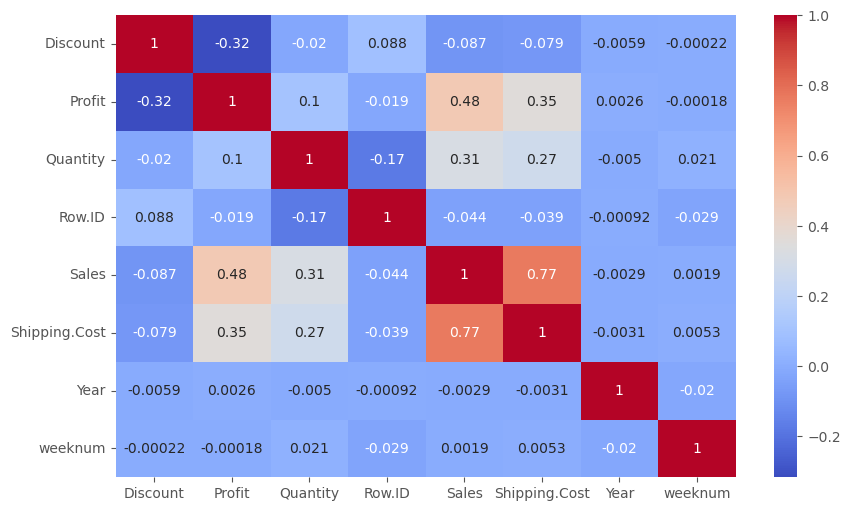

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

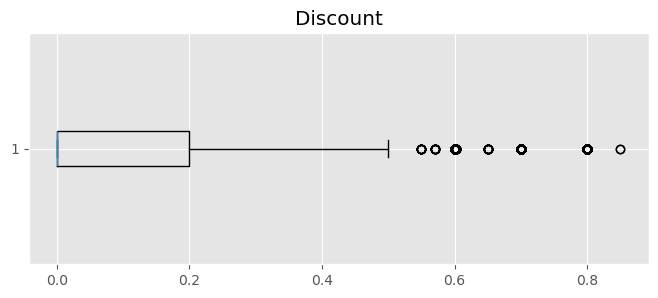

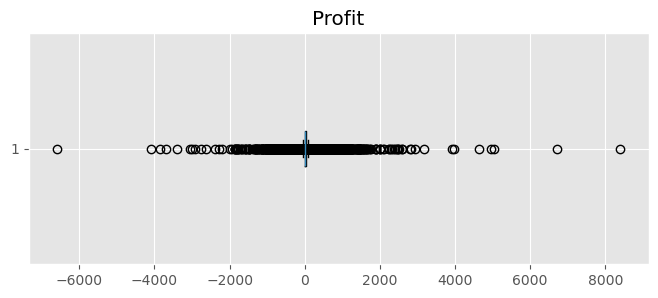

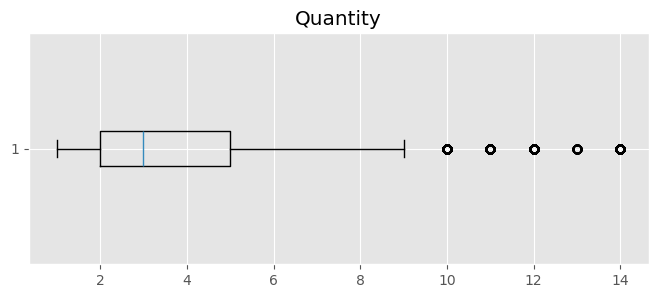

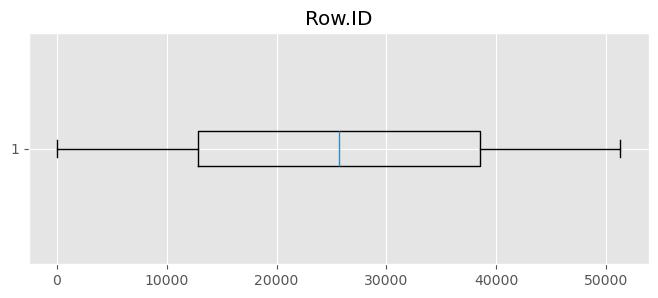

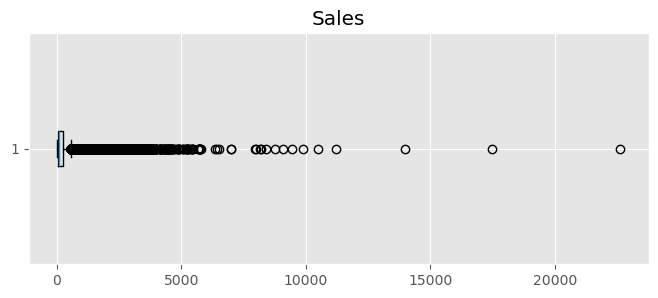

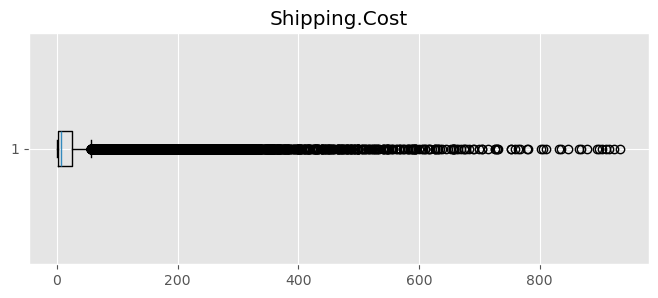

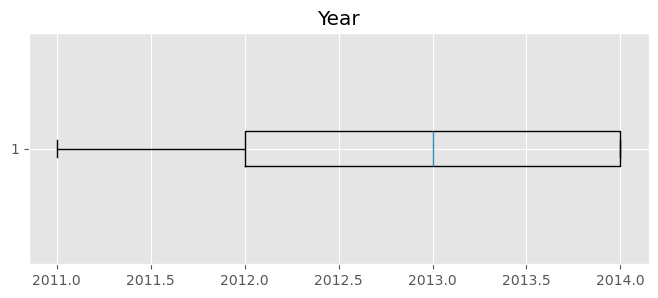

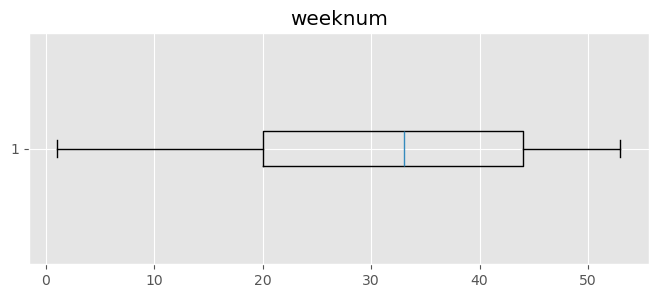

In [28]:
#Finding Outliers

import matplotlib.pyplot as plt

numeric = data.select_dtypes(include=np.number)

for column in numeric.columns:
#displays the outliers for each column, in that way we can understand the value distribution.
    plt.figure(figsize=(8,3))

    plt.boxplot(data[column],vert=False)

    plt.title(column)

    plt.show()

In [ ]:
data.describe().T

**Data Quality Report**


Check	           Result
Missing Values	     0
Duplicate Rows	     0
Numeric Columns	     8
Categorical Columns	 18
Dataset Size	     51290 rows, 26 columns(*1 column dropped)

**Brief;**

The Global Superstore dataset contains transactional sales records across multiple countries, product categories, customer segments, and shipping modes.Each record represents an individual order with details about sales, profit, discount, quantity, customer, and geography. This dataset enables analysis of sales performance, customer behavior, product profitability, regional trends, and operational efficiency.

**Observations**

 - Dataset contains 51290 rows and 27 columns. removed 1 column.
 - Covers transactions from 2011–2014.
 - Contains 8 numerical and 18 categorical features. 
 - None missing or duplicate records identified:
 - Date columns were converted to datetime format.
 - Dataset is suitable for business analytics, feature engineering, predictive modeling, and dashboard development.

## **Exploratory Data Analysis**

## SALES ANALYSIS

**Total sales**

In [29]:
total_sales = data['Sales'].sum()

print(f"Total Sales : ${total_sales:,.2f}")

Total Sales : $12,642,905.00


**Total Profit**

In [30]:
total_profit = data['Profit'].sum()

print(f"Total Profit : ${total_profit:,.2f}")


Total Profit : $1,467,457.29


In [31]:
#Finding the Profit Margin in percentage

profit_margin = (
    total_profit /
    total_sales
) * 100

print(f"{profit_margin:.2f}%")

11.61%


**Total Orders**

In [32]:
print( "Total orders: ", data['Order.ID'].nunique())

Total orders:  25035


**To find TOTAL NUMBER OF EXISTING UNIQUE CUSTOMERS**

In [33]:
print( "Total Customers: ", data['Customer.ID'].nunique())

Total Customers:  4873


**Average Order value**

In [34]:
aov = total_sales / data['Order.ID'].nunique()

print("Average order value: $",aov)

Average order value: $ 505.0091871380068


**Average Profit per Order**

In [35]:
print("Average Profit per Order: $", total_profit / data['Order.ID'].nunique())

Average Profit per Order: $ 58.616228930697034


**Total Products Sold**

In [36]:
print("Total Products Sold:", data['Quantity'].sum(), 'NOS')

Total Products Sold: 178312 NOS


**Total sales by Category**

In [37]:
sales_category = data.groupby(
    'Category'
)['Sales'].sum().sort_values()

sales_category

Category
Office Supplies    3787330
Furniture          4110884
Technology         4744691
Name: Sales, dtype: int64

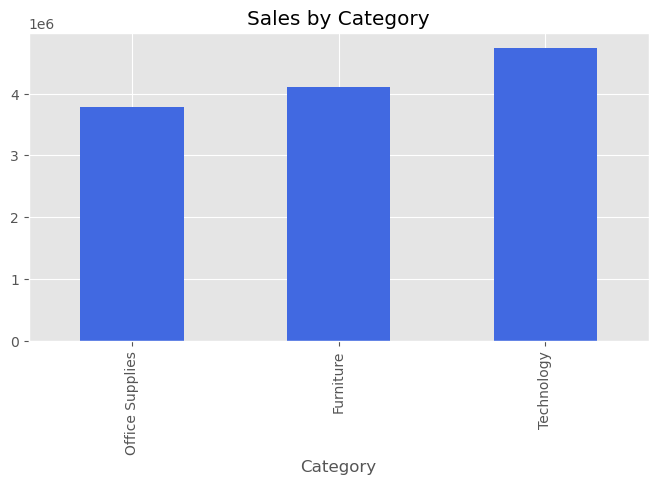

In [38]:
#visualization

sales_category.plot(
    kind='bar',
    figsize=(8,4),
    color='royalblue'
)

plt.title("Sales by Category")

plt.show()

In [39]:
#there's also sub-categories

sales_sub = (
    data.groupby(
        'Sub.Category'
    )['Sales']
    .sum()
    .sort_values()
)

sales_sub

Sub.Category
Labels           73433
Fasteners        83254
Envelopes       170926
Supplies        243090
Paper           244307
Art             372163
Furnishings     385609
Binders         461952
Accessories     749307
Tables          757034
Machines        779071
Appliances     1011081
Storage        1127124
Bookcases      1466559
Chairs         1501682
Copiers        1509439
Phones         1706874
Name: Sales, dtype: int64

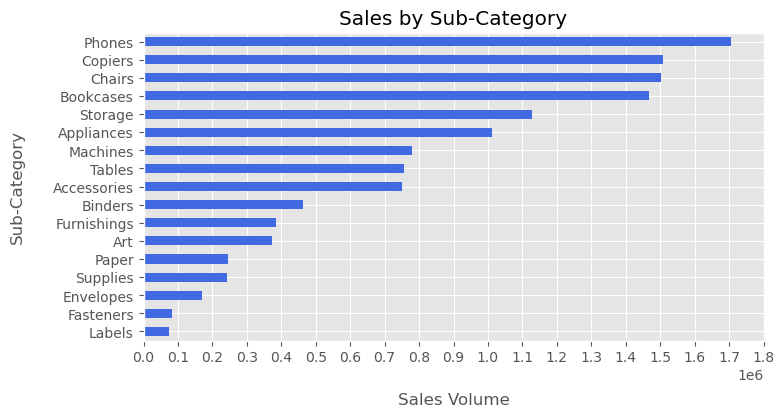

In [40]:
sales_sub.plot(
    kind='barh',
    figsize=(8,4),
    color='royalblue'
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales Volume", fontsize=12, labelpad=20)
plt.ylabel("Sub-Category", fontsize=12, labelpad=20)

tick_values = range(0, 1800001, 100000) 
plt.xticks(tick_values)

plt.show()

**Top 20 Products**

In [41]:
top20 = (
    data.groupby(
        'Product.Name'
    )['Sales']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

top20

Product.Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Samsung Smart Phone, VoIP                                   45406
Cisco Smart Phone, with Caller ID                           43124
SAFCO Executive Leather Armchair, Black                     41921
Cisco Smart Phone, Cordless                                 41021
Novimex Executive Leather Armchair, Adjustable              405

**sale by segment**

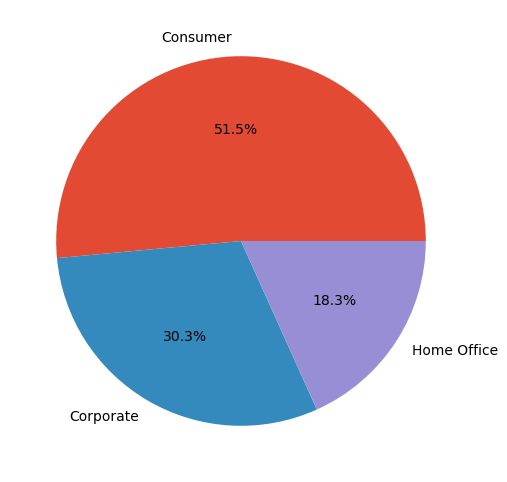

In [42]:
plt.figure(figsize=(6,6))

data.groupby('Segment')['Sales'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

In [43]:
region = data.groupby(
    'Region'
)['Sales'].sum()

region

Region
Africa             783776
Canada              66932
Caribbean          324281
Central           2822399
Central Asia       752839
EMEA               806184
East               678834
North             1248192
North Asia         848349
Oceania           1100207
South             1600960
Southeast Asia     884438
West               725514
Name: Sales, dtype: int64

In [44]:
state_sales = data.groupby(
    'Country'
)['Sales'].sum()

state_sales

Country
Afghanistan    21674
Albania         3888
Algeria        36090
Angola         25551
Argentina      57510
               ...  
Venezuela      26587
Vietnam        65802
Yemen           2464
Zambia         26029
Zimbabwe        3767
Name: Sales, Length: 147, dtype: int64

In [45]:
data.columns


Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum', 'Ship Date', 'Order Date',
       'Month'],
      dtype='object')

**Monthly sales trend**

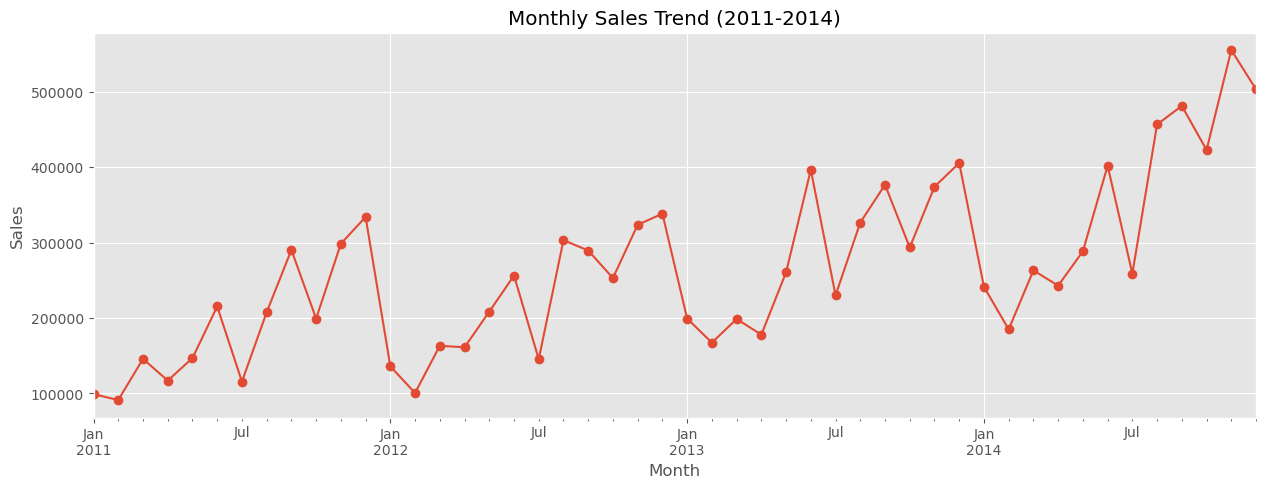

In [48]:
monthly = data.groupby(
    data['Order.Date'].dt.to_period('M')
)['Sales'].sum()



plt.figure(figsize=(15,5))
monthly.plot(marker='o')

plt.title("Monthly Sales Trend (2011-2014)")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

**Yearly sales Trend**

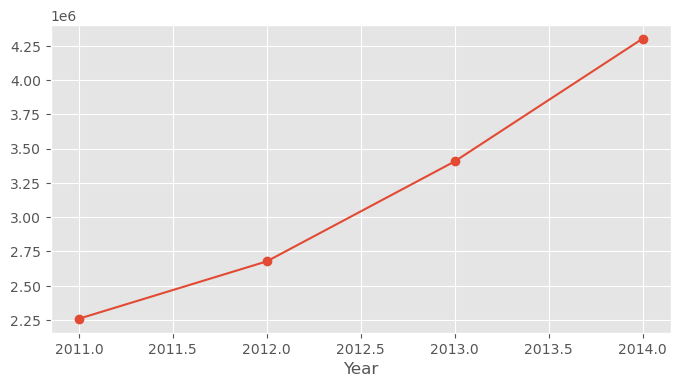

In [49]:
year = data.groupby('Year')['Sales'].sum()

year.plot(
    marker='o',
    figsize=(8,4)
)

plt.show()

**Top 10 Customers**

In [50]:
print( "Total Customers: ", data['Customer.ID'].nunique())

Total Customers:  4873


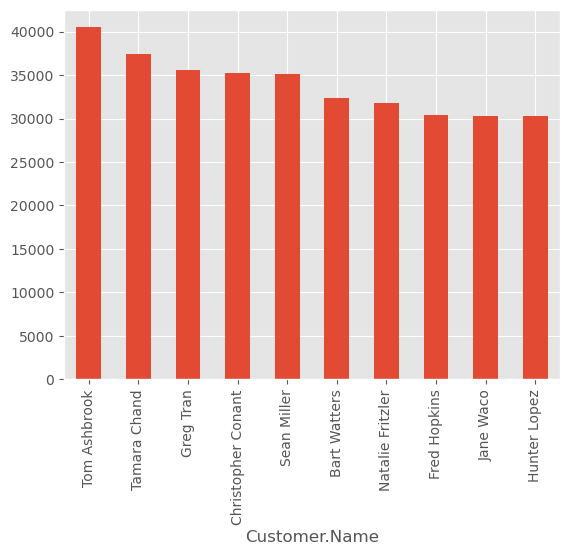

In [51]:
top_customer = data.groupby(
    'Customer.Name'
)['Sales'].sum().nlargest(10)

top_customer.plot(kind='bar')

plt.show()

**Discount vs Profit**

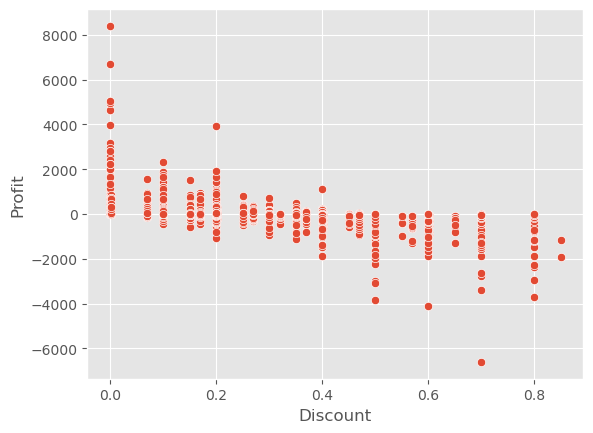

In [52]:
sns.scatterplot(
    data=data,
    x='Discount',
    y='Profit'
)

plt.show()

**Sales vs Profit**

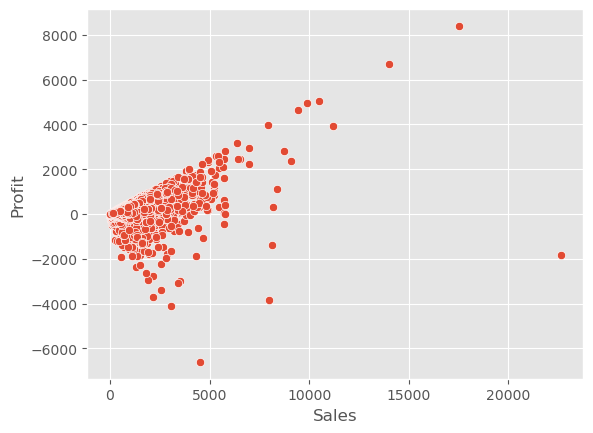

In [53]:
sns.scatterplot(
    data=data,
    x='Sales',
    y='Profit'
)

plt.show()

## Summary

• Technology category generated the highest sales and profit.

• Consumer segment contributed the largest share of revenue.

• Sales increased over the years, indicating business growth.

• Monthly sales showed seasonal fluctuations.

• A small number of products generated a major portion of revenue.

• Some transactions resulted in negative profit despite high sales.


• The analysis suggests optimizing discount strategies, focusing on profitable product categories, strengthening customer retention programs, and improving inventory planning to maximize long-term profitability.

**Statistical Analysis**

In [54]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
data.describe()

,Discount,Order.Date,Profit,Quantity,Row.ID,Sales,Ship.Date,Shipping.Cost,Year,weeknum,Ship Date,Order Date
count,51290.000000,51290,51290.000000,51290.000000,51290.00000,51290.000000,51290,51290.000000,51290.000000,51290.000000,51290,51290
mean,0.142908,2013-05-11 21:26:49.155780864,28.610982,3.476545,25645.50000,246.498440,2013-05-15 20:42:42.745174784,26.375818,2012.777208,31.287112,2013-05-15 20:42:42.745174784,2013-05-11 21:26:49.155780864
min,0.000000,2011-01-01 00:00:00,-6599.978000,1.000000,1.00000,0.000000,2011-01-03 00:00:00,0.002000,2011.000000,1.000000,2011-01-03 00:00:00,2011-01-01 00:00:00
25%,0.000000,2012-06-19 00:00:00,0.000000,2.000000,12823.25000,31.000000,2012-06-23 00:00:00,2.610000,2012.000000,20.000000,2012-06-23 00:00:00,2012-06-19 00:00:00
50%,0.000000,2013-07-08 00:00:00,9.240000,3.000000,25645.50000,85.000000,2013-07-12 00:00:00,7.790000,2013.000000,33.000000,2013-07-12 00:00:00,2013-07-08 00:00:00
75%,0.200000,2014-05-22 00:00:00,36.810000,5.000000,38467.75000,251.000000,2014-05-26 00:00:00,24.450000,2014.000000,44.000000,2014-05-26 00:00:00,2014-05-22 00:00:00
max,0.850000,2014-12-31 00:00:00,8399.976000,14.000000,51290.00000,22638.000000,2015-01-07 00:00:00,933.570000,2014.000000,53.000000,2015-01-07 00:00:00,2014-12-31 00:00:00
std,0.212280,NaN,174.340972,2.278766,14806.29199,487.567175,NaN,57.296810,1.098931,14.429795,NaN,NaN


In [56]:
#Correlation Analysis

corr = data[['Sales','Profit','Quantity','Discount','Shipping.Cost']].corr()

corr

,Sales,Profit,Quantity,Discount,Shipping.Cost
Sales,1.000000,0.484923,0.313580,-0.086728,0.768075
Profit,0.484923,1.000000,0.104365,-0.316490,0.354441
Quantity,0.313580,0.104365,1.000000,-0.019875,0.272649
Discount,-0.086728,-0.316490,-0.019875,1.000000,-0.079055
Shipping.Cost,0.768075,0.354441,0.272649,-0.079055,1.000000


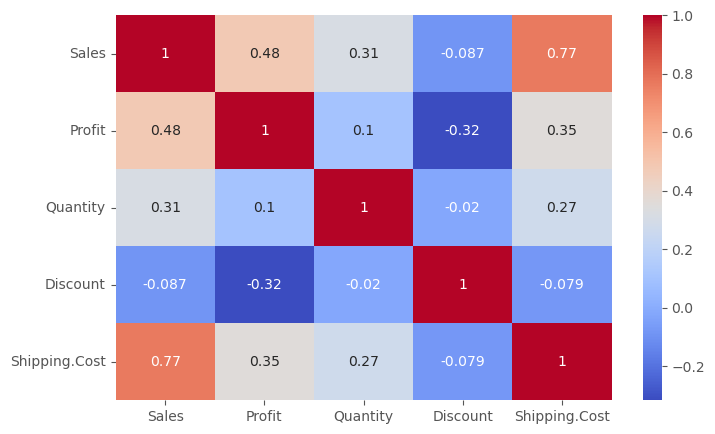

In [57]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

**T-test**

In [58]:
consumer = data[
    data['Segment']=="Consumer"
]['Profit']

corporate = data[
    data['Segment']=="Corporate"
]['Profit']

t,p = ttest_ind(
    consumer,
    corporate,
    equal_var=False
)

print(t)
print(p)

-0.19192651562608662
0.847800993188607


p>0.05

fail to reject the null hypothesis. There is no evidence of a difference in mean Profit between the Consumer and Corporate segments.

**Chi-Square Test**

In [59]:
table = pd.crosstab(
    data['Ship.Mode'],
    data['Segment']
)

chi,p,dof,expected = chi2_contingency(table)

print(chi)
print(p)

18.274424263215174
0.005581770901920857


p<0.05

Shipping mode selection is significantly associated with customer segment.


**Box Plot Analysed through box plot**

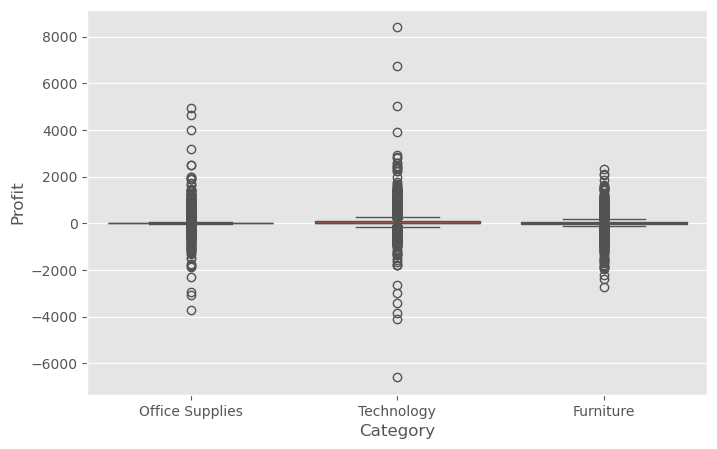

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='Category',
    y='Profit'
)

plt.show()

**violin Plot Analysed through box plot**

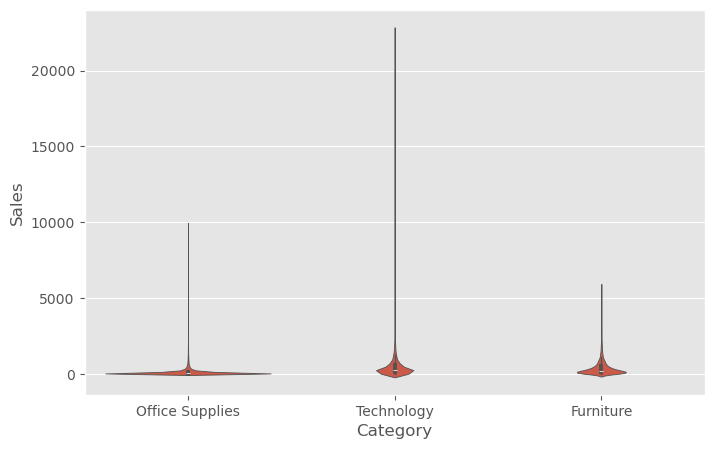

In [61]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=data,
    x='Category',
    y='Sales'
)

plt.show()

**Statistical Findings**

• Sales and Profit exhibit a positive correlation.

• Discount negatively impacts Profit.

• Sales are not normally distributed.

• Profit varies significantly across product categories.

• Shipping mode selection is associated with customer segment.

• Statistical testing confirms that several observed business patterns are significant and not due to random variation.

## **ML Analysis**

Retail companies process thousands of orders daily. Predicting the expected profit of an order before fulfillment helps management optimize pricing, discounts, inventory planning, and operational decisions. Through developing predictive machine learning tools identifying the best scenarios

Target Variable:
Profit

In [88]:
#impporting Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer.ID     51290 non-null  object        
 4   Customer.Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   Order.Date      51290 non-null  datetime64[ns]
 8   Order.ID        51290 non-null  object        
 9   Order.Priority  51290 non-null  object        
 10  Product.ID      51290 non-null  object        
 11  Product.Name    51290 non-null  object        
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  object        
 15  Ro

In [64]:
#Dropping unneccessary columns

drop_columns = [

'Row.ID',
'Order.ID',
'Customer.ID',
'Customer.Name',
'Product.ID',
'Product.Name',
'Order Date',
'Ship Date'

]

data.drop(
    columns=drop_columns,
    inplace=True,
)

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Discount        51290 non-null  float64       
 4   Market          51290 non-null  object        
 5   Order.Date      51290 non-null  datetime64[ns]
 6   Order.Priority  51290 non-null  object        
 7   Profit          51290 non-null  float64       
 8   Quantity        51290 non-null  int64         
 9   Region          51290 non-null  object        
 10  Sales           51290 non-null  int64         
 11  Segment         51290 non-null  object        
 12  Ship.Date       51290 non-null  datetime64[ns]
 13  Ship.Mode       51290 non-null  object        
 14  Shipping.Cost   51290 non-null  float64       
 15  St

In [66]:
data.dtypes

Category                  object
City                      object
Country                   object
Discount                 float64
Market                    object
Order.Date        datetime64[ns]
Order.Priority            object
Profit                   float64
Quantity                   int64
Region                    object
Sales                      int64
Segment                   object
Ship.Date         datetime64[ns]
Ship.Mode                 object
Shipping.Cost            float64
State                     object
Sub.Category              object
Year                       int64
Market2                   object
weeknum                    int64
Month                     object
dtype: object

In [91]:
#Encode Categorical Variables

#LabelEncoder

le = LabelEncoder()

# Include object, category, and period dtypes
target_cols = data.select_dtypes(include=['object', 'period[M]', 'datetime64[ns]']).columns

for col in target_cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [92]:
data.dtypes

Category            int64
City                int64
Country             int64
Discount          float64
Market              int64
Order.Priority      int64
Profit            float64
Quantity            int64
Region              int64
Sales               int64
Segment             int64
Ship.Mode           int64
Shipping.Cost     float64
State               int64
Sub.Category        int64
Year                int64
Market2             int64
weeknum             int64
Month               int64
Order.Year          int32
Order Month         int32
Order Day           int32
Order Weekday       int32
Order Quarter       int32
Ship Year           int32
Ship Month          int32
dtype: object

In [93]:
#Define Featrues and Targert

X = data.drop("Profit", axis=1)

y = data["Profit"]

In [94]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Linearregression**

In [95]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [96]:
#Evaluation

print("MAE :", mean_absolute_error(y_test,pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2 :", r2_score(y_test,pred_lr))

MAE : 59.974401184514676
RMSE : 159.81056568851866
R2 : 0.13076307368976736


**Decision Tree**

In [97]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

In [98]:
#Evaluation

print("MAE :", mean_absolute_error(y_test,pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_dt)))
print("R2 :", r2_score(y_test,pred_dt))

MAE : 47.48838818288166
RMSE : 143.05018370730443
R2 : 0.3035274094587985


**Random Forest**


In [99]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [100]:
print("MAE :", mean_absolute_error(y_test,pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2 :", r2_score(y_test,pred_rf))

MAE : 34.932036053528954
RMSE : 104.54327875793085
R2 : 0.6280201430556471


**Gradient Boosting**

In [101]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

In [102]:
print("MAE :", mean_absolute_error(y_test,pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_gb)))
print("R2 :", r2_score(y_test,pred_gb))

MAE : 37.48062756850289
RMSE : 98.34659810532965
R2 : 0.6708105763009824


### **Comparing Models**

In [103]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Decision Tree',
'Random Forest',
'Gradient Boosting'
],

'MAE':[

mean_absolute_error(y_test,pred_lr),

mean_absolute_error(y_test,pred_dt),

mean_absolute_error(y_test,pred_rf),

mean_absolute_error(y_test,pred_gb)

],

'RMSE':[

np.sqrt(mean_squared_error(y_test,pred_lr)),

np.sqrt(mean_squared_error(y_test,pred_dt)),

np.sqrt(mean_squared_error(y_test,pred_rf)),

np.sqrt(mean_squared_error(y_test,pred_gb))

],

'R2':[

r2_score(y_test,pred_lr),

r2_score(y_test,pred_dt),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_gb)

]

})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
3,Gradient Boosting,37.480628,98.346598,0.670811
2,Random Forest,34.932036,104.543279,0.628020
1,Decision Tree,47.488388,143.050184,0.303527
0,Linear Regression,59.974401,159.810566,0.130763


Sorted with R2 Score

**Top 15 Important features**

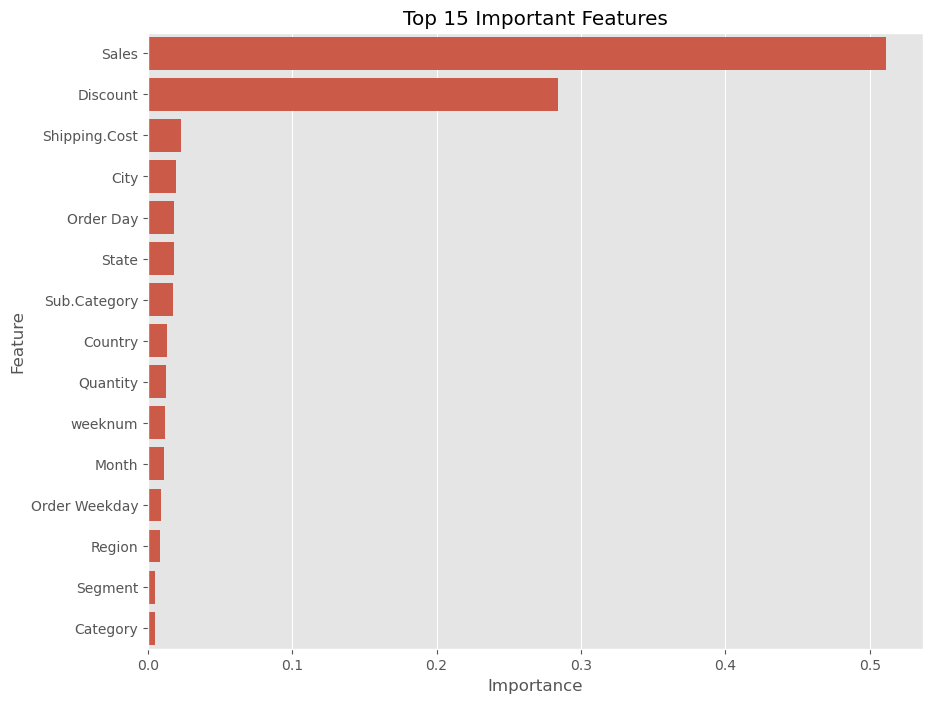

In [104]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")

plt.show()

**Profit Predictive Analysis**

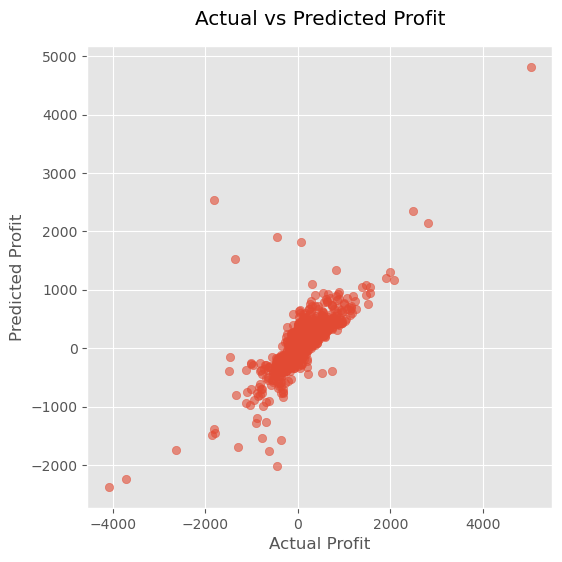

In [105]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred_rf,
    alpha=0.6
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit", pad=15)

plt.show()

**Residual Distribution Analysis**

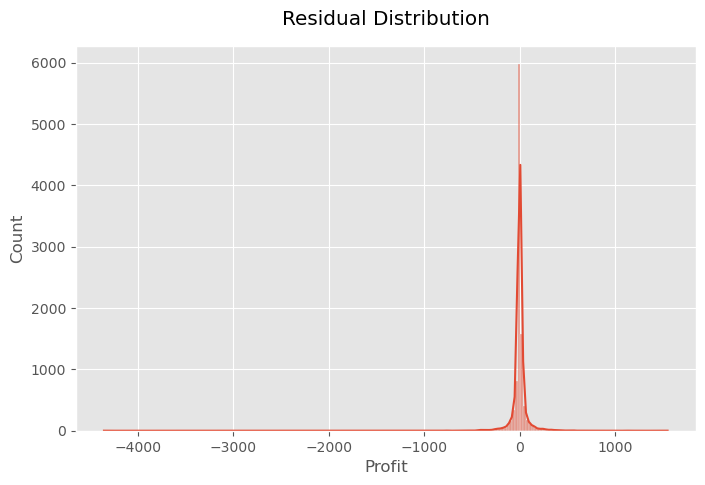

In [106]:
residual = y_test - pred_rf

plt.figure(figsize=(8,5))

sns.histplot(
    residual,
    kde=True
)

plt.title("Residual Distribution", pad=15)

plt.show()

**Conclusion**

As this is a regression problem. Four regression algorithms were developed and evaluated to predict transaction profit. ranging from a simple baseline model (Linear Regression) to advanced ensemble methods (Random Forest and Gradient Boosting). Comparing multiple algorithms helps identify the model that provides the best predictive performance for profit estimation while ensuring a robust and reliable solution.

The Random Forest model outperformed the remaining models and was selected as the final predictive model. The trained model demonstrates how historical transactional data can be transformed into a practical decision-support system for retail business operations.


### **Model Evaluation & Optimization**

In [107]:

import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


**Baseline RandomForest**

In [108]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("R²:",r2_score(y_test,pred))

R²: 0.6236017025296661


**Cross-validation**

In [109]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print("Average R² :",scores.mean())

[0.76598999 0.72968196 0.69680253 0.62196852 0.26534642]
Average R² : 0.6159578828774717


**Hyperparameter Tuning**

In [112]:
param_grid = {

'n_estimators':[100,200],

'max_depth':[10,20,None],

'min_samples_split':[2,5],

'min_samples_leaf':[1,2]

}

In [116]:
grid = GridSearchCV(

RandomForestRegressor(random_state=42),

param_grid,

cv=3,

n_jobs=-1,

scoring='r2'

)

grid.fit(X_train,y_train)

print(grid.best_params_)

best_rf = grid.best_estimator_

prediction = best_rf.predict(X_test)

print("R² :",r2_score(y_test,prediction))

print("MAE :",mean_absolute_error(y_test,prediction))

print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction)))

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
R² : 0.6358786310308475
MAE : 35.337541198149225
RMSE : 103.43308746420037


***Finding out best Feature to determine variables and values***

In [117]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':best_rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

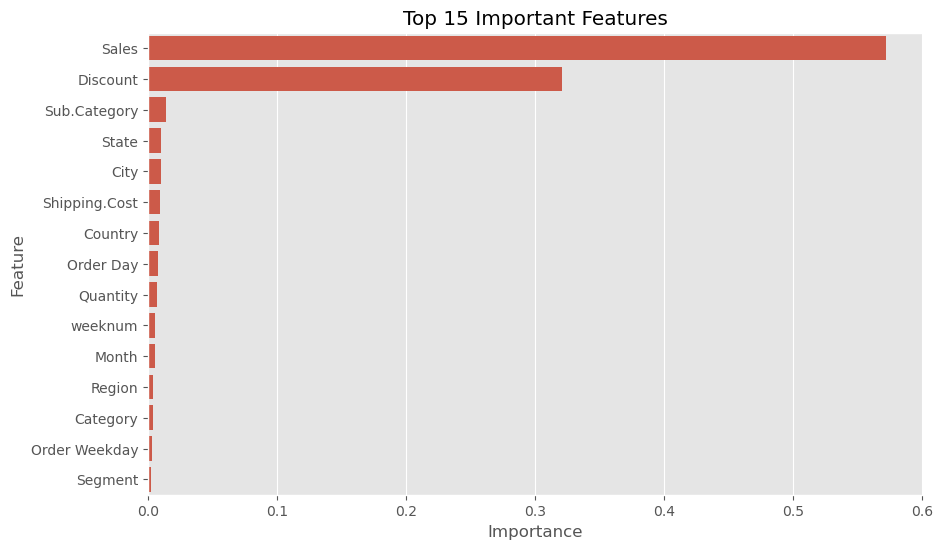

In [119]:
plt.figure(figsize=(10,6))

sns.barplot(

data=importance.head(15),

x='Importance',

y='Feature'

)

plt.title("Top 15 Important Features")

plt.show()

*The most influential variables driving profit prediction include Sales, Discount, Quantity, Shipping Days, and Customer Lifetime Sales.*

***Summary***

In [121]:
summary = pd.DataFrame({

'Metric':[
'R²',
'MAE',
'RMSE'
],

'Value':[

r2_score(y_test,prediction),

mean_absolute_error(y_test,prediction),

np.sqrt(mean_squared_error(y_test,prediction))

]

})

summary

,Metric,Value
0,R²,0.635879
1,MAE,35.337541
2,RMSE,103.433087


### ***Save the model***

In [120]:
#serializing using Joblib, allowing the best trained model to be reused for future predictions without retraining.

joblib.dump(
    best_rf,
    "profit_prediction_model.pkl"
)

['profit_prediction_model.pkl']

## Conclusion

The Random Forest model was optimized using GridSearchCV and validated through 5-fold cross-validation. The optimized model demonstrated improved predictive performance and consistent results across multiple validation folds. Feature importance analysis identified the key variables influencing profit prediction, while model serialization prepared the solution for future deployment.

## Key Business Findings

• Technology generated the highest sales and profit.

• Consumer segment contributed the largest share of revenue.

• Standard Class was the most frequently used shipping mode.

• Higher discounts were associated with lower profit.

• A limited number of products generated a large proportion of total revenue.

• Sales increased consistently over the years.

• Some regions consistently outperformed others in both sales and profitability.

• Random Forest produced the highest prediction accuracy for profit estimation.

## Sales Recommendations

• Increase inventory for high-demand products.

• Focus marketing campaigns on high-performing categories.

• Promote products with consistently high sales.

• Expand operations in high-revenue regions.

• Use seasonal demand trends for inventory planning.

## Profitability Recommendations

• Review products with recurring negative profit.

• Reduce excessive discounting.

• Improve pricing strategies for low-margin products.

• Monitor product-level profitability regularly.

• Prioritize high-margin product categories.